<a href="https://colab.research.google.com/github/tarannump096-cpu/NLP/blob/main/Hourly_energy_demand_generation_and_weather.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor

In [37]:
energy = pd.read_csv("/content/energy_dataset.csv")
weather = pd.read_csv("/content/weather_features.csv")

print(energy.head())
print(weather.head())

                        time  generation biomass  \
0  2015-01-01 00:00:00+01:00               447.0   
1  2015-01-01 01:00:00+01:00               449.0   
2  2015-01-01 02:00:00+01:00               448.0   
3  2015-01-01 03:00:00+01:00               438.0   
4  2015-01-01 04:00:00+01:00               428.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 328.0                                 0.0   
2                                 323.0                                 0.0   
3                                 254.0                                 0.0   
4                                 187.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 5196.0                       4755.

In [38]:
energy = energy.rename(columns={'time': 'datetime'})
weather = weather.rename(columns={'dt_iso': 'datetime'})

energy['datetime'] = pd.to_datetime(energy['datetime'], errors='coerce', utc=True)
weather['datetime'] = pd.to_datetime(weather['datetime'], errors='coerce', utc=True)

# Merge on datetime
data = pd.merge(energy, weather, on='datetime', how='inner')

print(data.head())

                   datetime  generation biomass  \
0 2014-12-31 23:00:00+00:00               447.0   
1 2014-12-31 23:00:00+00:00               447.0   
2 2014-12-31 23:00:00+00:00               447.0   
3 2014-12-31 23:00:00+00:00               447.0   
4 2014-12-31 23:00:00+00:00               447.0   

   generation fossil brown coal/lignite  generation fossil coal-derived gas  \
0                                 329.0                                 0.0   
1                                 329.0                                 0.0   
2                                 329.0                                 0.0   
3                                 329.0                                 0.0   
4                                 329.0                                 0.0   

   generation fossil gas  generation fossil hard coal  generation fossil oil  \
0                 4844.0                       4821.0                  162.0   
1                 4844.0                       4821.0     

In [39]:
import numpy as np

# Ensure datetime column is datetime type
data['datetime'] = pd.to_datetime(data['datetime'], errors='coerce', utc=True)

# Time features
data['hour'] = data['datetime'].dt.hour
data['day_of_week'] = data['datetime'].dt.dayofweek
data['month'] = data['datetime'].dt.month

# Weekend flag
data['is_weekend'] = data['day_of_week'].isin([5,6]).astype(int)

# Lag features (VERY IMPORTANT)
data['lag_1'] = data['total load actual'].shift(1)
data['lag_24'] = data['total load actual'].shift(24)

# Rolling feature
data['rolling_mean_24'] = data['total load actual'].rolling(24).mean()

# Fill missing numerical values with the mean instead of dropping rows
numerical_cols = data.select_dtypes(include=np.number).columns
for col in numerical_cols:
    if data[col].isnull().any():
        data[col].fillna(data[col].mean(), inplace=True)

/tmp/ipykernel_14753/1943960284.py:25: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].mean(), inplace=True)


In [40]:
features = [
    'temp', 'humidity', 'wind_speed',
    'hour', 'day_of_week', 'month', 'is_weekend',
    'lag_1', 'lag_24', 'rolling_mean_24'
]

X = data[features]
y = data['total load actual']

In [41]:
split = int(len(data) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [42]:
print('Shape of X_train:', X_train.shape)
print('Shape of X_test:', X_test.shape)

Shape of X_train: (142716, 10)
Shape of X_test: (35680, 10)


In [43]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8
)

model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=8,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

In [44]:
y_pred = model.predict(X_test)


In [45]:
print(energy['datetime'].dtype)

datetime64[ns, UTC]


In [49]:
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 240.6052164491636
RMSE: 443.4987564027907


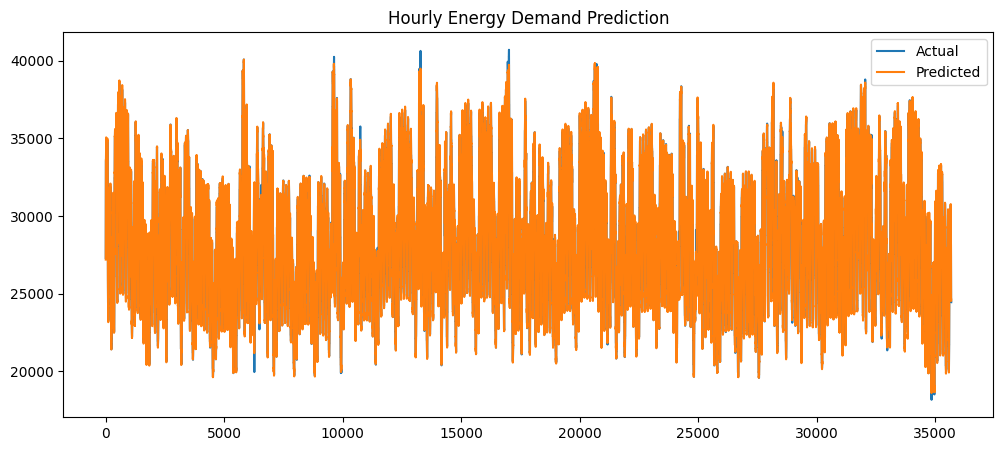

In [50]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.legend()
plt.title("Hourly Energy Demand Prediction")
plt.show()

In [51]:
def predict_next_hour(last_row, model):
    features = last_row[[
        'temperature','humidity','wind_speed',
        'hour','day_of_week','month','is_weekend',
        'lag_1','lag_24','rolling_mean_24'
    ]].values.reshape(1, -1)

    return model.predict(features)[0]